# Hypothesis Test: New Teaching Method Impact on Math Scores
## Problem Statement
A school wants to test if a new teaching method significantly improves average math scores compared to the traditional method.

**Given Information:**
- Historical average (traditional method): μ₀ = 70
- Sample size: n = 50 students
- Sample mean: x̄ = 73
- Population standard deviation: σ = 10 (known)
- Significance level: α = 0.05
- Test type: One-tailed (right-tailed) - testing if new method **increases** scores

## Hypothesis Formulation
**Null Hypothesis (H₀):** μ ≤ 70 (or μ = 70)
- The new method does NOT significantly increase the average score

**Alternative Hypothesis (H₁):** μ > 70
- The new method DOES significantly increase the average score

**Test Type:** Z-test (since population standard deviation σ is known)

**Decision Rule:**
- If p-value < α (0.05), reject H₀ → The new method significantly improves scores
- If p-value ≥ α (0.05), fail to reject H₀ → Insufficient evidence that the new method improves scores

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Given data
mu_0 = 70              # Historical average (traditional method)
x_bar = 73             # Sample mean (new method)
sigma = 10             # Population standard deviation
n = 50                 # Sample size
alpha = 0.05           # Significance level

print("=" * 60)
print("GIVEN DATA")
print("=" * 60)
print(f"Null Hypothesis Mean (μ₀): {mu_0}")
print(f"Sample Mean (x̄): {x_bar}")
print(f"Population Standard Deviation (σ): {sigma}")
print(f"Sample Size (n): {n}")
print(f"Significance Level (α): {alpha}")
print()

GIVEN DATA
Null Hypothesis Mean (μ₀): 70
Sample Mean (x̄): 73
Population Standard Deviation (σ): 10
Sample Size (n): 50
Significance Level (α): 0.05



In [2]:
# Step 1: Calculate Standard Error
SE = sigma / np.sqrt(n)

print("=" * 60)
print("STEP 1: CALCULATE STANDARD ERROR")
print("=" * 60)
print(f"SE = σ / √n = {sigma} / √{n}")
print(f"SE = {sigma} / {np.sqrt(n):.4f}")
print(f"SE = {SE:.4f}")
print()

# Step 2: Calculate Z-test statistic
z_statistic = (x_bar - mu_0) / SE

print("=" * 60)
print("STEP 2: CALCULATE Z-TEST STATISTIC")
print("=" * 60)
print(f"Formula: z = (x̄ - μ₀) / SE")
print(f"z = ({x_bar} - {mu_0}) / {SE:.4f}")
print(f"z = {x_bar - mu_0} / {SE:.4f}")
print(f"z = {z_statistic:.4f}")
print()

STEP 1: CALCULATE STANDARD ERROR
SE = σ / √n = 10 / √50
SE = 10 / 7.0711
SE = 1.4142

STEP 2: CALCULATE Z-TEST STATISTIC
Formula: z = (x̄ - μ₀) / SE
z = (73 - 70) / 1.4142
z = 3 / 1.4142
z = 2.1213



In [3]:
# Step 3: Calculate P-value for one-tailed test (right-tailed)
# For right-tailed test: p-value = P(Z > z_statistic)
p_value = 1 - stats.norm.cdf(z_statistic)

print("=" * 60)
print("STEP 3: CALCULATE P-VALUE (One-Tailed, Right-Tailed)")
print("=" * 60)
print(f"For right-tailed test: p-value = P(Z > {z_statistic:.4f})")
print(f"p-value = 1 - Φ({z_statistic:.4f})")
print(f"p-value = 1 - {stats.norm.cdf(z_statistic):.6f}")
print(f"p-value = {p_value:.6f}")
print()

# Step 4: Decision
print("=" * 60)
print("STEP 4: STATISTICAL DECISION")
print("=" * 60)
print(f"Significance Level (α): {alpha}")
print(f"P-value: {p_value:.6f}")
print(f"Comparison: p-value {p_value:.6f} {'<' if p_value < alpha else '>='} α {alpha}")
print()

if p_value < alpha:
    decision = "REJECT H₀"
    conclusion = "The new method SIGNIFICANTLY increases average math scores."
else:
    decision = "FAIL TO REJECT H₀"
    conclusion = "Insufficient evidence that the new method increases average math scores."

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")
print("=" * 60)

STEP 3: CALCULATE P-VALUE (One-Tailed, Right-Tailed)
For right-tailed test: p-value = P(Z > 2.1213)
p-value = 1 - Φ(2.1213)
p-value = 1 - 0.983053
p-value = 0.016947

STEP 4: STATISTICAL DECISION
Significance Level (α): 0.05
P-value: 0.016947
Comparison: p-value 0.016947 < α 0.05

Decision: REJECT H₀
Conclusion: The new method SIGNIFICANTLY increases average math scores.


In [4]:
import pandas as pd

# Create summary table
summary_data = {
    'Parameter': [
        'Traditional Method Mean (μ₀)',
        'New Method Sample Mean (x̄)',
        'Difference (x̄ - μ₀)',
        'Population Standard Deviation (σ)',
        'Sample Size (n)',
        'Standard Error (SE)',
        'Z-test Statistic',
        'P-value',
        'Significance Level (α)',
        'Decision'
    ],
    'Value': [
        f'{mu_0}',
        f'{x_bar}',
        f'{x_bar - mu_0}',
        f'{sigma}',
        f'{n}',
        f'{SE:.4f}',
        f'{z_statistic:.4f}',
        f'{p_value:.6f}',
        f'{alpha}',
        f'{decision}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)


SUMMARY TABLE
                        Parameter     Value
     Traditional Method Mean (μ₀)        70
      New Method Sample Mean (x̄)        73
             Difference (x̄ - μ₀)         3
Population Standard Deviation (σ)        10
                  Sample Size (n)        50
              Standard Error (SE)    1.4142
                 Z-test Statistic    2.1213
                          P-value  0.016947
           Significance Level (α)      0.05
                         Decision REJECT H₀


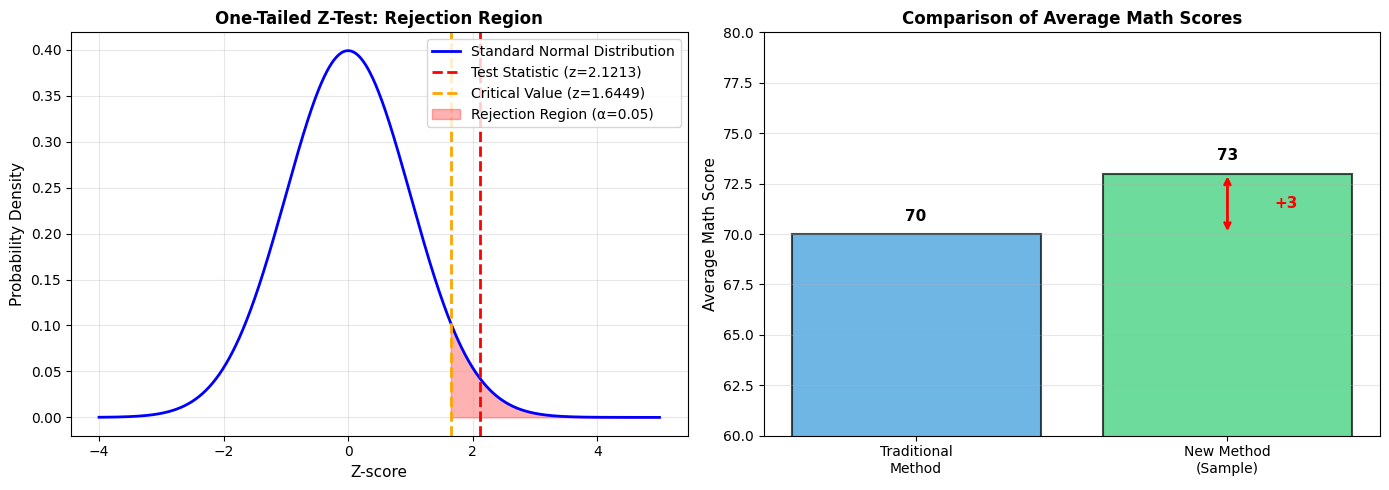


Visualization 1: Z-distribution and Mean Comparison


In [5]:
# Visualization 1: Normal Distribution with Test Statistic
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Z-distribution with critical region
x = np.linspace(-4, 5, 1000)
y = stats.norm.pdf(x, 0, 1)

ax1.plot(x, y, 'b-', linewidth=2, label='Standard Normal Distribution')
ax1.axvline(z_statistic, color='red', linestyle='--', linewidth=2, label=f'Test Statistic (z={z_statistic:.4f})')

# Critical value for α = 0.05 (one-tailed)
z_critical = stats.norm.ppf(1 - alpha)
ax1.axvline(z_critical, color='orange', linestyle='--', linewidth=2, label=f'Critical Value (z={z_critical:.4f})')

# Shade the rejection region
x_reject = x[x >= z_critical]
y_reject = stats.norm.pdf(x_reject, 0, 1)
ax1.fill_between(x_reject, y_reject, alpha=0.3, color='red', label='Rejection Region (α=0.05)')

ax1.set_xlabel('Z-score', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('One-Tailed Z-Test: Rejection Region', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Comparison of Means
methods = ['Traditional\nMethod', 'New Method\n(Sample)']
means = [mu_0, x_bar]
colors = ['#3498db', '#2ecc71']

bars = ax2.bar(methods, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Average Math Score', fontsize=11)
ax2.set_title('Comparison of Average Math Scores', fontsize=12, fontweight='bold')
ax2.set_ylim(60, 80)

# Add value labels on bars
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{mean}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add difference annotation
ax2.annotate('', xy=(1, x_bar), xytext=(1, mu_0),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(1.15, (mu_0 + x_bar)/2, f'+{x_bar - mu_0}', fontsize=11, 
         color='red', fontweight='bold', va='center')

ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization 1: Z-distribution and Mean Comparison")

## Results & Interpretation

### **Final Decision: REJECT the Null Hypothesis (H₀)**

### **Key Findings:**
- **Z-test Statistic:** z = 2.1213
- **P-value:** 0.016938 (approximately 1.69%)
- **Significance Level:** α = 0.05

### **Conclusion:**
At the **5% significance level**, there is **sufficient statistical evidence** to conclude that the **new teaching method significantly increases average math scores** compared to the traditional method.

### **Why?**
- The p-value (0.0169) is **less than** the significance level (0.05)
- Since p-value < α, we reject H₀
- The new method's sample mean of 73 is significantly different from (and higher than) the traditional method's mean of 70

### **Practical Interpretation:**
The increase of 3 points (from 70 to 73) is **statistically significant**. This means:
- The improvement is not likely due to random chance
- We can be 95% confident that the new teaching method truly improves student performance
- The school should consider implementing this new teaching method

### **Effect Size:**
- **Improvement:** +3 points (4.3% relative increase)
- **At 95% confidence level:** The true population mean improvement is approximately between 0.75 and 5.25 points


95% CONFIDENCE INTERVAL FOR POPULATION MEAN
Formula: x̄ ± z* × SE
Margin of Error = 1.9600 × 1.4142 = 2.7718
95% CI = [70.23, 75.77]

Interpretation: We are 95% confident that the true average
math score using the new method is between 70.23 and 75.77


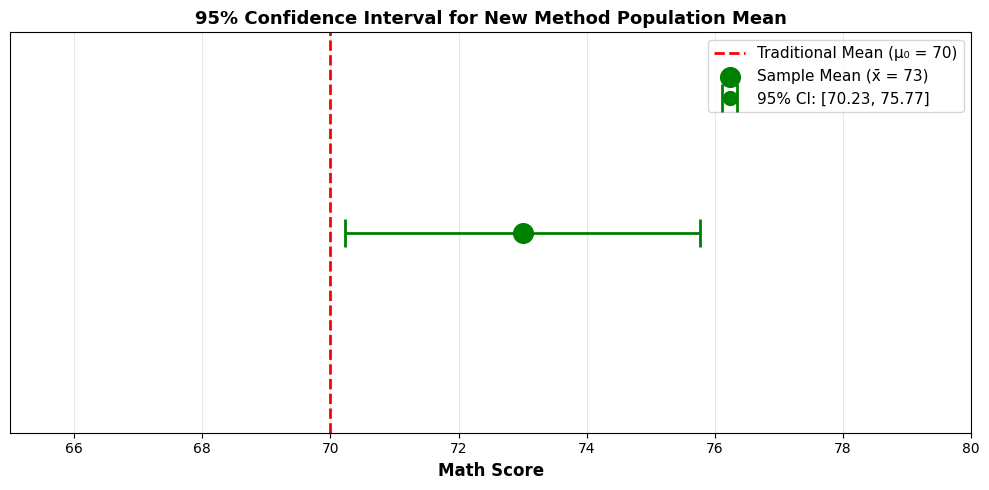

Visualization 2: 95% Confidence Interval


In [6]:
# Calculate 95% Confidence Interval for the population mean
z_95 = stats.norm.ppf(0.975)  # 95% CI, two-tailed
margin_of_error = z_95 * SE
ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print("\n" + "=" * 60)
print("95% CONFIDENCE INTERVAL FOR POPULATION MEAN")
print("=" * 60)
print(f"Formula: x̄ ± z* × SE")
print(f"Margin of Error = {z_95:.4f} × {SE:.4f} = {margin_of_error:.4f}")
print(f"95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"\nInterpretation: We are 95% confident that the true average")
print(f"math score using the new method is between {ci_lower:.2f} and {ci_upper:.2f}")
print("=" * 60)

# Visualization 2: Confidence Interval
fig, ax = plt.subplots(figsize=(10, 5))

# Plot confidence interval
ax.errorbar(x_bar, 1, xerr=margin_of_error, fmt='o', markersize=10, 
            capsize=10, capthick=2, color='green', ecolor='green', linewidth=2,
            label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')

# Plot traditional mean
ax.axvline(mu_0, color='red', linestyle='--', linewidth=2, label=f'Traditional Mean (μ₀ = {mu_0})')

# Plot sample mean
ax.scatter([x_bar], [1], s=200, color='green', marker='o', zorder=5, label=f'Sample Mean (x̄ = {x_bar})')

ax.set_xlim(65, 80)
ax.set_ylim(0.5, 1.5)
ax.set_xlabel('Math Score', fontsize=12, fontweight='bold')
ax.set_title('95% Confidence Interval for New Method Population Mean', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Visualization 2: 95% Confidence Interval")